# Fed-Drift 🏦
### Do stocks quietly drift up the day before a Fed meeting?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Still an edge after publication?: Not supported](https://img.shields.io/badge/Still_an_edge_after_publication%3F-Not_supported-8b949e?style=flat-square)

One of the strangest facts in markets: for two decades, almost all of the stock market's gains arrived in the 24 hours *before* scheduled Fed announcements. Just ~3% of trading days — the day before each FOMC meeting — carried a *fifth* of the market's entire return. Then academics published it, and it vanished.

> 📓 **Plain-language layer.** The drift table, the t-stat, and the pre/post-publication split are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every number is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (fed_drift/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from fed_drift import data, strategy as st
ret, fomc = data.fetch_panel()                 # cache-first (shared SPY pull)


## The answer first 🎯

| The question | The data (SPY, 1993–2026) |
|---|---|
| "Do stocks drift up pre-FOMC?" | Yes: **+0.17%/day vs +0.04%**, 3% of days = 11.5% of return. |
| "Was it big?" | Pre-2011, those ~3% of days earned **19.8%** of the market's total return. |
| "Can you trade it now?" | No — post-2011 it decayed to a normal day (t 0.4). |

## 1 · The claim

Lucca & Moench (2015): in the 24 hours before a scheduled FOMC statement, equities earn an outsized, oddly reliable return — enough to explain most of the post-1994 equity premium. The folk version: *something leaks, or risk gets repriced, right before the Fed speaks.*

## 2 · So what?

If true and persistent, it's a calendar you could trade with a known schedule years in advance — be long into the pre-FOMC day, flat otherwise. The question is whether it survived being one of the most-cited findings in modern finance.

## 3 · How would we even know?

Tag the trading session just before each of 264 scheduled FOMC announcements since 1993, compare SPY's return on those days to every other day, and split the sample at 2011 (when the paper circulated) to see if the edge decayed.

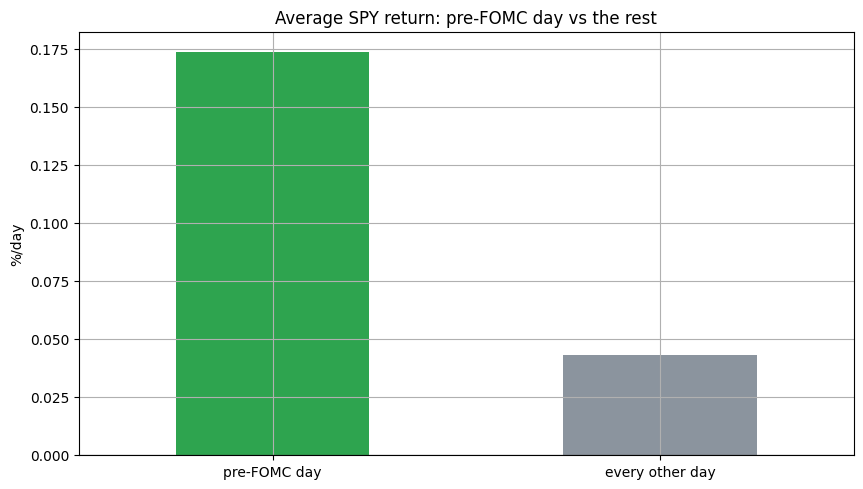

264 pre-FOMC days = 3.1% of sessions, 11.5% of cumulative return


In [2]:
t=st.drift_table(ret,fomc,lead=1)
bars=pd.Series({'pre-FOMC day':t['pre_mean'],'every other day':t['rest_mean']})*100
ax=bars.plot.bar(rot=0,color=['#2ea44f','#8b949e'],title='Average SPY return: pre-FOMC day vs the rest')
ax.set_ylabel('%/day'); ax.axhline(0,color='k',lw=.8); plt.show()
print(f"{t['n_pre']} pre-FOMC days = {t['n_pre']/t['n_total']:.1%} of sessions, {t['pre_share']:.1%} of cumulative return")

## 4 · The teardown — it was real, then it died

Split at the 2011 publication era: before, the pre-FOMC day was a giant; after, it's just another day.

In [3]:
sp=st.split_by_date(ret,fomc,cut='2011-01-01')
tab=pd.DataFrame({e:{'pre-FOMC %/day':v['pre_mean']*100,'other %/day':v['rest_mean']*100,'share of return %':v['pre_share']*100} for e,v in sp.items()}).T
display(tab.round(2))
for e,v in sp.items(): print(f"{e}: diff t~{v['tstat']:.2f}")

,pre-FOMC %/day,other %/day,share of return %
pre_publication,0.24,0.03,19.81
post_publication,0.09,0.06,5.18


pre_publication: diff t~1.68
post_publication: diff t~0.37


**Read it plainly.** 1993–2010: the pre-FOMC day averaged +0.24% and ~3% of sessions earned **19.8%** of the market's whole return. 2011–2026: +0.09%, a difference t of 0.4, just 5% of return. The anomaly was front-run into oblivion once everyone knew the schedule.

## 5 · The verdict

**Signal: Real** — a documented, economically enormous historical drift. **Tradability: Fragile** — it decayed on publication. **Still an edge after publication?: Not supported.** Textbook post-publication decay.

## 6 · Could you actually trade it?

Not anymore. It was real and huge — but it was also famous, and a schedule everyone can see is the easiest thing in the world to arbitrage. The money was made by those holding the position *before* the 2011 paper; after, the edge is gone.

## 7 · Going further 🚪

A post-publication-decay cousin of the timing studies [56 Tide-Table](../../56-tide-table/) (CAPE) and [66 Inverted](../../66-inverted/) (yield curve), and a calendar sibling of [55 Summer-Lull](../../55-summer-lull/). Forks: the FOMC-cycle even-week pattern (Cieslak et al.), intraday windows, other scheduled macro releases.